🔄 임베딩 모델 로딩 중...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ 벡터화 완료!
질문: 안녕하세요

🔴 [키워드 검색]
✅ 매칭 성공
안녕하세요. → Bonjour.

🔵 [임베딩 검색 (RAG)]
✅ 매칭 성공 (유사도: 0.98)
안녕하세요. → Bonjour.
질문: 카페에서 인사하는 표현

🔴 [키워드 검색]
❌ 매칭 실패

🔵 [임베딩 검색 (RAG)]
✅ 매칭 성공 (유사도: 0.51)
커피 한 잔 주세요. → Un café s'il vous plaît.
질문: 아침에 하는 인사

🔴 [키워드 검색]
❌ 매칭 실패

🔵 [임베딩 검색 (RAG)]
✅ 매칭 성공 (유사도: 0.69)
아침 식사. → Le petit-déjeuner.

📊 성능 결과
키워드 검색: 33.3%
RAG 검색: 100.0%


c:\Users\KDS30\anaconda3\envs\new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KDS30\anaconda3\envs\new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KDS30\anaconda3\envs\new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KDS30\anaconda3\envs\new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\KDS30\anaconda3\envs\new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from fo

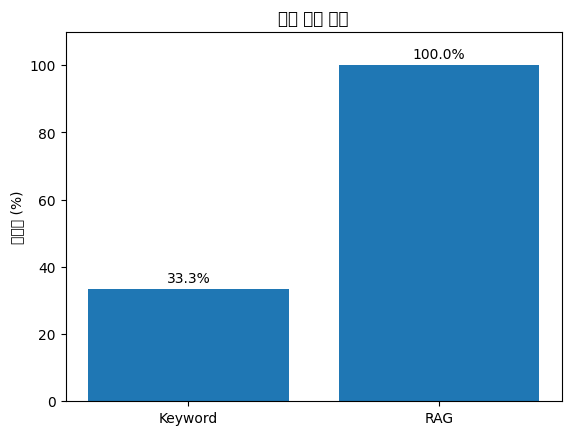

🚀 최종 챗봇 테스트

질문: 안녕하세요


AuthenticationError: Error code: 401 - {'error': {'message': "You didn't provide an API key. You need to provide your API key in an Authorization header using Bearer auth (i.e. Authorization: Bearer YOUR_KEY), or as the password field (with blank username) if you're accessing the API from your browser and are prompted for a username and password. You can obtain an API key from https://platform.openai.com/account/api-keys.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [6]:
# %%
# =========================================
# [Step 0] 라이브러리
# =========================================
import pandas as pd
import torch
import re
from sentence_transformers import SentenceTransformer, util
from openai import OpenAI
import matplotlib.pyplot as plt

# %%
# =========================================
# [Step 1] 데이터 로드
# =========================================
def load_data(file_path):
    try:
        return pd.read_csv(file_path, encoding='utf-8')
    except:
        return pd.read_csv(file_path, encoding='cp949')

df = load_data('french.csv')
df['korean'] = df['korean'].fillna("")

# %%
# =========================================
# [Step 2] 키워드 검색 (Baseline)
# =========================================
def find_relevant_data_keyword(user_query):
    query = re.sub(r'[?.!, ]', '', str(user_query)).lower()
    
    for _, row in df.iterrows():
        db_korean = re.sub(r'[?.!, ]', '', str(row['korean'])).lower()
        if query in db_korean or db_korean in query:
            return row
    return None

# %%
# =========================================
# [Step 3] 임베딩 기반 RAG 구축
# =========================================
print("🔄 임베딩 모델 로딩 중...")
embedder = SentenceTransformer('jhgan/ko-sroberta-multitask')

corpus = df['korean'].tolist()
corpus_embeddings = embedder.encode(corpus, convert_to_tensor=True)
print("✅ 벡터화 완료!")

def find_relevant_data_vector(user_query, threshold=0.5):
    query_embedding = embedder.encode(user_query, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]

    best_score = torch.max(cos_scores).item()
    best_idx = torch.argmax(cos_scores).item()

    if best_score >= threshold:
        return df.iloc[best_idx], best_score
    else:
        return None, best_score

# %%
# =========================================
# [Step 4] OpenAI 설정
# =========================================
token = ""  # 🔑 API KEY 입력
client = OpenAI(api_key=token)

# %%
# =========================================
# [Step 5] 챗봇 함수 (공통)
# =========================================
def generate_response(prompt, temperature=0.5, top_p=0.8):
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        top_p=top_p,
        max_tokens=500
    )
    return response.choices[0].message.content.strip()

# %%
# =========================================
# [Step 6] 키워드 vs RAG 비교 출력
# =========================================
def compare_search_methods(question):
    
    keyword_result = find_relevant_data_keyword(question)
    vector_result, score = find_relevant_data_vector(question)

    print("="*80)
    print(f"질문: {question}")
    print("="*80)

    # 🔴 키워드
    print("\n🔴 [키워드 검색]")
    if keyword_result is not None:
        print("✅ 매칭 성공")
        print(keyword_result['korean'], "→", keyword_result['french'])
    else:
        print("❌ 매칭 실패")

    # 🔵 RAG
    print("\n🔵 [임베딩 검색 (RAG)]")
    if vector_result is not None:
        print(f"✅ 매칭 성공 (유사도: {score:.2f})")
        print(vector_result['korean'], "→", vector_result['french'])
    else:
        print("❌ 매칭 실패")

# %%
# =========================================
# [Step 7] 성능 테스트
# =========================================
test_questions = [
    "안녕하세요",
    "카페에서 인사하는 표현",
    "아침에 하는 인사"
]

keyword_success = 0
vector_success = 0

for q in test_questions:
    compare_search_methods(q)

    if find_relevant_data_keyword(q) is not None:
        keyword_success += 1

    if find_relevant_data_vector(q)[0] is not None:
        vector_success += 1

# %%
# =========================================
# [Step 8] 성능 그래프
# =========================================
keyword_rate = keyword_success / len(test_questions) * 100
vector_rate = vector_success / len(test_questions) * 100

print("\n📊 성능 결과")
print(f"키워드 검색: {keyword_rate:.1f}%")
print(f"RAG 검색: {vector_rate:.1f}%")

labels = ['Keyword', 'RAG']
values = [keyword_rate, vector_rate]

plt.figure()
plt.bar(labels, values)

plt.title('검색 성능 비교')
plt.ylabel('성공률 (%)')

for i, v in enumerate(values):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center')

plt.ylim(0, 110)
plt.show()

# %%
# =========================================
# [Step 9] RAG 챗봇 (최종)
# =========================================
def get_tutor_response(question, temperature=0.5, top_p=0.8):

    matched_data, score = find_relevant_data_vector(question)

    if matched_data is not None:
        prompt = f"""
다음 정보를 기반으로 설명하세요:

문장: {matched_data['french']}
뜻: {matched_data['korean']}
발음: {matched_data['pronunciation']}
"""
    else:
        prompt = question

    return generate_response(prompt, temperature, top_p)

# %%
# =========================================
# [Step 10] 최종 테스트
# =========================================
print("="*80)
print("🚀 최종 챗봇 테스트")
print("="*80)

for q in test_questions:
    print("\n질문:", q)
    print(get_tutor_response(q))